<a href="https://colab.research.google.com/github/shivanshi-09/weather_modelling/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize
from joblib import Parallel, delayed
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, SMOTENC
from collections import Counter
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
import os
warnings.filterwarnings('ignore')
df = pd.read_csv("https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_diabetes_clean.csv")

In [ ]:
TARGET_COL = 'diabetes_label'

# Tier 1: zero-cost (scale + BP cuff, demographics)
FEATURE_COLS_T1 = ['RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'BMXBMI', 'BMXWAIST', 'BPXSY_mean', 'BPXDI_mean']

# Tier 2: adds basic blood panel (requires blood draw)
FEATURE_COLS_T2 = ['LBXTC', 'LBXTR', 'LBXSCR', 'LBXSUA', 'LBXSBU']

# Tier 3: adds full biochemistry panel
FEATURE_COLS_T3 = ['LBXSATSI', 'LBXSASSI', 'LBXSTP', 'LBXSAL', 'LBXSCA', 'LBXSPH', 'LBXSNASI', 'LBXSKSI', 'LBXSGB', 'LBXSC3SI']

ALL_FEATURE_COLS = FEATURE_COLS_T1 + FEATURE_COLS_T2 + FEATURE_COLS_T3

DEFAULT_CONFIG = {
    'learning_rate': 0.1,
    'max_depth': 6,
    'n_estimators': 300,
    'colsample_bytree': 0.75,
    'subsample': 0.8,
}

PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth':    [4, 6, 8],
    # 'learning_rate':    [0.01, 0.1, 0.2],
    # 'subsample':        [0.6, 0.8, 1.0],
    # 'colsample_bytree': [0.5, 0.75, 1.0],
}

TEST_SIZE   = 0.2
RANDOM_SEED = 42

In [ ]:
def load_data(path):
    df = pd.read_csv(path)
    print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
    print('Label distribution:')
    print(df[TARGET_COL].value_counts().sort_index().rename({0: 'Normal', 1: 'Pre-diabetic', 2: 'Diabetic'}))
    return df


def split_data(df, feature_cols=ALL_FEATURE_COLS):
    X = df[feature_cols].values
    y = df[TARGET_COL].values

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
        )

    X_train, X_cal, y_train, y_cal = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_temp
    )

    print(f'Train: {X_train.shape[0]} | Cal: {X_cal.shape[0]} | Test: {X_test.shape[0]}')
    return X_train, X_cal, X_test, y_train, y_cal, y_test
X_train, X_cal, X_test, y_train, y_cal, y_test = split_data(df)

Train: 3627 | Cal: 1209 | Test: 1209


In [ ]:
class Model:
    def __init__(self, config=DEFAULT_CONFIG, n_jobs=2):
        self.model = XGBClassifier(
            **config,
            objective='multi:softprob',
            num_class=3,
            random_state=RANDOM_SEED,
            n_jobs=n_jobs,
        )
        self.is_fitted = False
        self.config = config


def train_model(model, X_train, y_train):
    model.model.fit(X_train, y_train)
    model.is_fitted = True
    train_loss = loss(model, X_train, y_train)
    print(f'Train log-loss: {train_loss:.4f}')
    return model


def pred(model, X):
    if not model.is_fitted:
        raise RuntimeError('untrained model')
    return model.model.predict(X)


def pred_proba(model, X):
    if not model.is_fitted:
        raise RuntimeError('untrained model')
    return model.model.predict_proba(X)


def loss(model, X, y):
    proba = pred_proba(model, X)
    eps = 1e-15
    return -np.mean([np.log(proba[i, y[i]] + eps) for i in range(len(y))])


def evaluate(model, X_test, y_test, label='XGBoost'):
    preds  = pred(model, X_test)
    probas = pred_proba(model, X_test)
    f1_mac = f1_score(y_test, preds, average='macro')
    f1_per = f1_score(y_test, preds, average=None)
    y_bin  = label_binarize(y_test, classes=[0, 1, 2])
    auroc  = roc_auc_score(y_bin, probas, multi_class='ovr', average='macro')
    auprc  = average_precision_score(y_bin, probas, average='macro')
    print(f'{label}')
    print(f'  Macro F1:  {f1_mac:.4f}')
    print(f'  F1 per class (Normal / Pre-diab / Diabetic): {f1_per[0]:.3f} / {f1_per[1]:.3f} / {f1_per[2]:.3f}')
    print(f'  AUROC:     {auroc:.4f}')
    print(f'  AUPRC:     {auprc:.4f}')
    return preds, probas, f1_mac, auroc, auprc

In [ ]:
xgb_model = Model(config=DEFAULT_CONFIG)
xgb_model = train_model(xgb_model, X_train, y_train)
xgb_preds, xgb_probas, xgb_f1, xgb_auroc, xgb_auprc = evaluate(xgb_model, X_test, y_test, label='XGBoost (all tiers)')

Train log-loss: 0.0683
XGBoost (all tiers)
  Macro F1:  0.5321
  F1 per class (Normal / Pre-diab / Diabetic): 0.796 / 0.438 / 0.363
  AUROC:     0.8027
  AUPRC:     0.5807


In [ ]:
def grid_search(X_train, y_train, X_cal, y_cal, n_jobs=2, top_n=5):
    def train_eval(config):
        model = Model(config=config)
        model.model.fit(X_train, y_train)
        model.is_fitted = True
        val_loss = loss(model, X_cal, y_cal)
        return {'model': model, 'config': config, 'val_loss': val_loss}

    combos = list(ParameterGrid(PARAM_GRID))
    print(f'Testing {len(combos)} configurations on calibration set ...')

    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(train_eval)(config) for config in combos
    )

    sorted_res = sorted(results, key=lambda x: x['val_loss'])[:top_n]

    print(f'Top {top_n} configurations (by calibration log-loss):')
    for i, r in enumerate(sorted_res):
        print(f'  Rank {i+1} | Cal Loss: {r["val_loss"]:.4f} | Config: {r["config"]}')

    return sorted_res


top  = grid_search(X_train, y_train, X_cal, y_cal)
best = top[0]['model']

Testing 9 configurations on calibration set ...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Top 5 configurations (by calibration log-loss):
  Rank 1 | Cal Loss: 0.7354 | Config: {'max_depth': 4, 'n_estimators': 100}
  Rank 2 | Cal Loss: 0.8384 | Config: {'max_depth': 6, 'n_estimators': 100}
  Rank 3 | Cal Loss: 0.8895 | Config: {'max_depth': 4, 'n_estimators': 300}
  Rank 4 | Cal Loss: 0.9145 | Config: {'max_depth': 8, 'n_estimators': 100}
  Rank 5 | Cal Loss: 1.0117 | Config: {'max_depth': 4, 'n_estimators': 500}


[Parallel(n_jobs=2)]: Done   9 out of   9 | elapsed:   15.6s finished


In [ ]:
best_preds, best_probas, best_f1, best_auroc, best_auprc = evaluate(best, X_test, y_test, label='XGBoost (best config)')

XGBoost (best config)
  Macro F1:  0.5174
  F1 per class (Normal / Pre-diab / Diabetic): 0.791 / 0.419 / 0.342
  AUROC:     0.7937
  AUPRC:     0.5659


In [ ]:
tier_configs = [
    ('Tier 1 (zero-cost)',  FEATURE_COLS_T1),
    ('Tier 1+2 (moderate)', FEATURE_COLS_T1 + FEATURE_COLS_T2),
    ('Tier 1+2+3 (full)',   ALL_FEATURE_COLS),
]

tier_results = []
tier_models  = {}
tier_proba_cal  = {}
tier_proba_test = {}
tier_y_cal  = {}
tier_y_test = {}

for tier_label, feature_cols in tier_configs:
    Xtr, Xca, Xte, ytr, yca, yte = split_data(df, feature_cols=feature_cols)
    m = Model(config=top[0]['config'])
    m = train_model(m, Xtr, ytr)
    _, _, f1, auroc, auprc = evaluate(m, Xte, yte, label=tier_label)
    tier_results.append({'tier': tier_label, 'f1': f1, 'auroc': auroc, 'auprc': auprc})

    tier_models[tier_label]     = m
    tier_proba_cal[tier_label]  = pred_proba(m, Xca)
    tier_proba_test[tier_label] = pred_proba(m, Xte)
    tier_y_cal[tier_label]      = yca
    tier_y_test[tier_label]     = yte

Train: 3627 | Cal: 1209 | Test: 1209
Train log-loss: 0.4512
Tier 1 (zero-cost)
  Macro F1:  0.4815
  F1 per class (Normal / Pre-diab / Diabetic): 0.781 / 0.420 / 0.244
  AUROC:     0.7639
  AUPRC:     0.5211
Train: 3627 | Cal: 1209 | Test: 1209
Train log-loss: 0.3696
Tier 1+2 (moderate)
  Macro F1:  0.5039
  F1 per class (Normal / Pre-diab / Diabetic): 0.788 / 0.431 / 0.292
  AUROC:     0.7910
  AUPRC:     0.5504
Train: 3627 | Cal: 1209 | Test: 1209
Train log-loss: 0.2977
Tier 1+2+3 (full)
  Macro F1:  0.5174
  F1 per class (Normal / Pre-diab / Diabetic): 0.791 / 0.419 / 0.342
  AUROC:     0.7937
  AUPRC:     0.5659


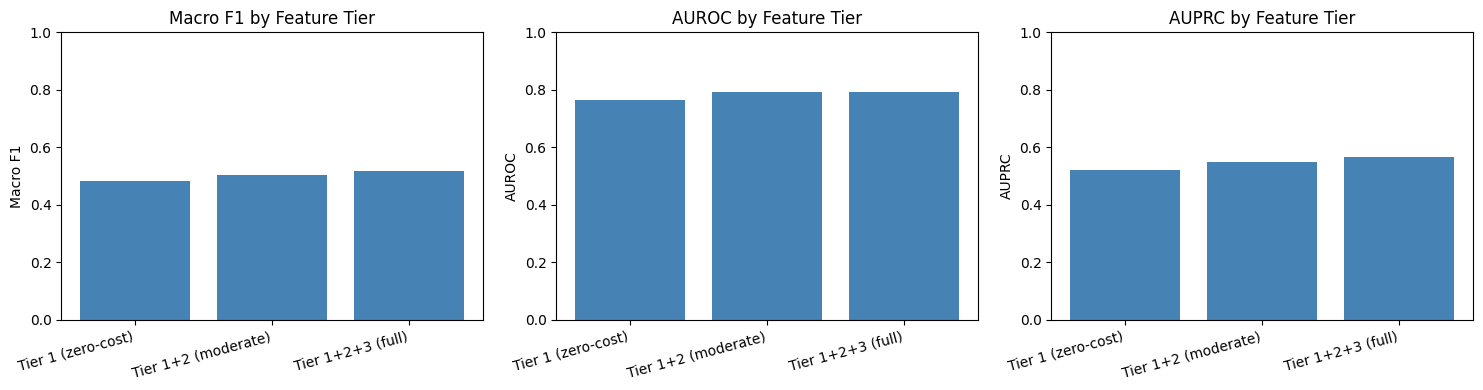

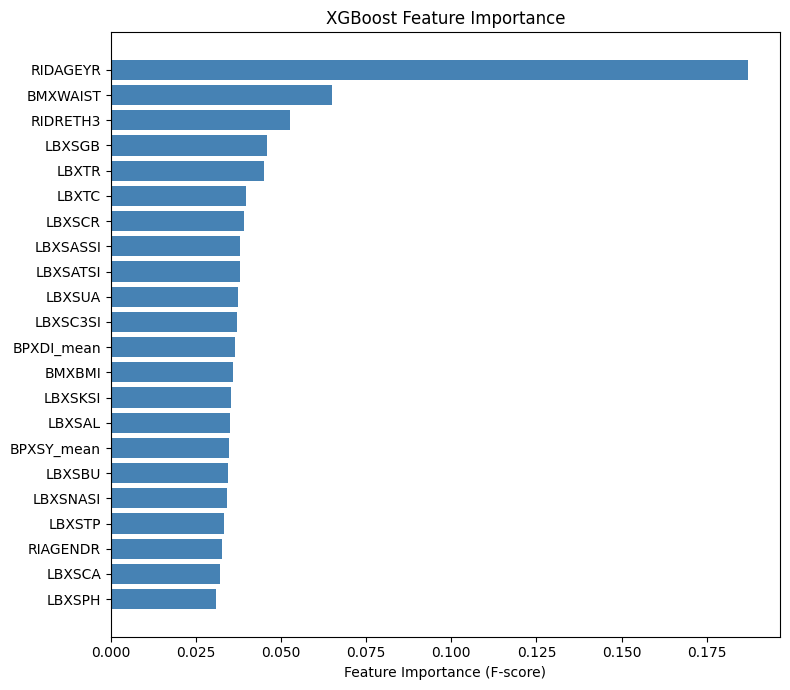

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tier_labels = [r['tier'] for r in tier_results]
f1s    = [r['f1']    for r in tier_results]
aurocs = [r['auroc'] for r in tier_results]
auprcs = [r['auprc'] for r in tier_results]

for ax, vals, metric in zip(axes, [f1s, aurocs, auprcs], ['Macro F1', 'AUROC', 'AUPRC']):
    ax.bar(range(len(tier_labels)), vals, color='steelblue')
    ax.set_xticks(range(len(tier_labels)))
    ax.set_xticklabels(tier_labels, rotation=15, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Feature Tier')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('diabetes_tier_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

importances = best.model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_features    = [ALL_FEATURE_COLS[i] for i in indices]
sorted_importances = importances[indices]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
ax.set_xlabel('Feature Importance (F-score)')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('diabetes_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
_, df_test = train_test_split(
    df.reset_index(drop=True),
    test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=df[TARGET_COL]
)
df_test = df_test.copy()
df_test['pred_label'] = best_preds

def ablation_report(df, split_col, split_labels, title):
    print(f'Ablation: {title}')
    for val, label in split_labels.items():
        subset = df[df[split_col] == val]
        f1 = f1_score(subset[TARGET_COL], subset['pred_label'], average='macro', zero_division=0)
        print(f'  {label:20s} | n={len(subset):5d} | Macro F1: {f1:.3f}')

df_test['age_group'] = pd.cut(df_test['RIDAGEYR'], bins=[18, 40, 60, 100], labels=['18-40', '40-60', '60+'])
print('Ablation: Age group')
for grp in ['18-40', '40-60', '60+']:
    subset = df_test[df_test['age_group'] == grp]
    f1 = f1_score(subset[TARGET_COL], subset['pred_label'], average='macro', zero_division=0)
    print(f'  {grp:20s} | n={len(subset):5d} | Macro F1: {f1:.3f}')

ablation_report(df_test, 'RIAGENDR', {1: 'Male', 2: 'Female'}, 'Sex')

Ablation: Age group
  18-40                | n=  344 | Macro F1: 0.495
  40-60                | n=  328 | Macro F1: 0.472
  60+                  | n=  359 | Macro F1: 0.423
Ablation: Sex
  Male                 | n=  587 | Macro F1: 0.511
  Female               | n=  622 | Macro F1: 0.524


In [ ]:
print(f'XGBoost (default) | F1: {xgb_f1:.4f} | AUROC: {xgb_auroc:.4f} | AUPRC: {xgb_auprc:.4f}')
print(f'XGBoost (tuned)   | F1: {best_f1:.4f} | AUROC: {best_auroc:.4f} | AUPRC: {best_auprc:.4f}')
print(f'\nBest config: {top[0]["config"]}')

XGBoost (default) | F1: 0.5321 | AUROC: 0.8027 | AUPRC: 0.5807
XGBoost (tuned)   | F1: 0.5174 | AUROC: 0.7937 | AUPRC: 0.5659

Best config: {'max_depth': 4, 'n_estimators': 100}


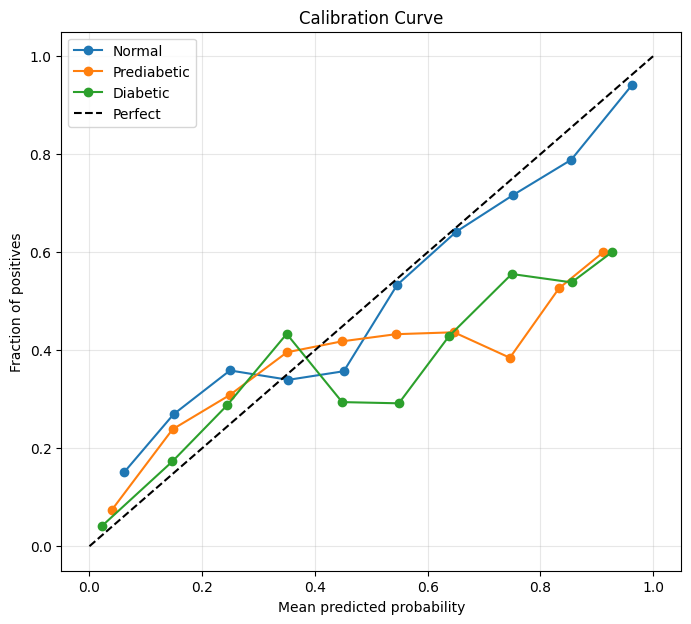

In [ ]:
plt.figure(figsize=(8, 7))
for k, name, color in zip([0, 1, 2], ['Normal', 'Prediabetic', 'Diabetic'],
                           ['#1f77b4', '#ff7f0e', '#2ca02c']):
    frac_pos, mean_pred = calibration_curve((y_test == k).astype(int), best_probas[:, k], n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', color=color, label=name)

plt.plot([0, 1], [0, 1], 'k--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
cal_probas = pred_proba(best, X_cal)
t_space = np.linspace(0.1, 0.9, 81)
optimal_thresholds = []

for c in range(3):
    actual_positive = (y_cal == c)
    best_t, best_f1_t = 0.5, 0.0
    for t in t_space:
        preds_t = (cal_probas[:, c] >= t)
        tp = np.sum(actual_positive & preds_t)
        fp = np.sum(~actual_positive & preds_t)
        fn = np.sum(actual_positive & ~preds_t)
        f1_t = 2 * tp / (2 * tp + fp + fn + 1e-9)
        if f1_t > best_f1_t:
            best_f1_t, best_t = f1_t, t
    optimal_thresholds.append(best_t)

print('Optimal thresholds per class (Normal / Prediabetic / Diabetic):',
      [f'{t:.2f}' for t in optimal_thresholds])

Optimal thresholds per class (Normal / Prediabetic / Diabetic): ['0.46', '0.21', '0.18']


In [ ]:
class KMeans:
    def __init__(self, n_clusters=8, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters   = n_clusters
        self.max_iter     = max_iter
        self.tol          = tol
        self.random_state = random_state

    def _pairwise_sq_dist(self, X, C):
        return ((X ** 2).sum(axis=1)[:, None]
                + (C ** 2).sum(axis=1)[None, :]
                - 2.0 * X @ C.T)

    def _kmeans_plus_plus(self, X, rng):
        n = X.shape[0]
        centroids = np.empty((self.n_clusters, X.shape[1]))
        centroids[0] = X[rng.randint(n)]
        for k in range(1, self.n_clusters):
            d2 = self._pairwise_sq_dist(X, centroids[:k]).min(axis=1)
            d2 = np.clip(d2, 0, None)
            total = d2.sum()
            if total == 0:
                centroids[k] = X[rng.randint(n)]
            else:
                centroids[k] = X[rng.choice(n, p=d2 / total)]
        return centroids

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.RandomState(self.random_state)
        centroids = self._kmeans_plus_plus(X, rng)

        for it in range(self.max_iter):
            dists  = self._pairwise_sq_dist(X, centroids)
            labels = dists.argmin(axis=1)

            new_centroids = np.empty_like(centroids)
            for k in range(self.n_clusters):
                pts = X[labels == k]
                if len(pts) > 0:
                    new_centroids[k] = pts.mean(axis=0)
                else:
                    new_centroids[k] = X[rng.randint(X.shape[0])]

            shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            if shift < self.tol:
                break

        dists  = self._pairwise_sq_dist(X, centroids)
        labels = dists.argmin(axis=1)
        self.cluster_centers_ = centroids
        self.labels_          = labels
        self.inertia_         = float(dists[np.arange(X.shape[0]), labels].sum())
        self.n_iter_          = it + 1
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._pairwise_sq_dist(X, self.cluster_centers_).argmin(axis=1)

    def fit_predict(self, X):
        return self.fit(X).labels_


In [ ]:
class PCA:
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n_samples, n_features = X.shape
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        cov = (Xc.T @ Xc) / (n_samples - 1)
        eigvals, eigvecs = np.linalg.eigh(cov)
        order   = np.argsort(eigvals)[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]
        components = eigvecs.T
        max_abs    = np.argmax(np.abs(components), axis=1)
        signs      = np.sign(components[np.arange(components.shape[0]), max_abs])
        components = components * signs[:, None]
        k = self.n_components if self.n_components is not None else n_features
        total_var = eigvals.sum()

        self.components_               = components[:k]
        self.explained_variance_       = eigvals[:k]
        self.explained_variance_ratio_ = eigvals[:k] / total_var
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

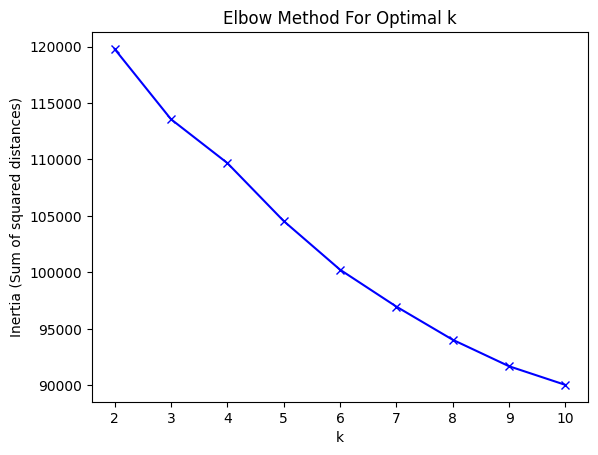

In [ ]:
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[ALL_FEATURE_COLS])

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method For Optimal k')
plt.show()

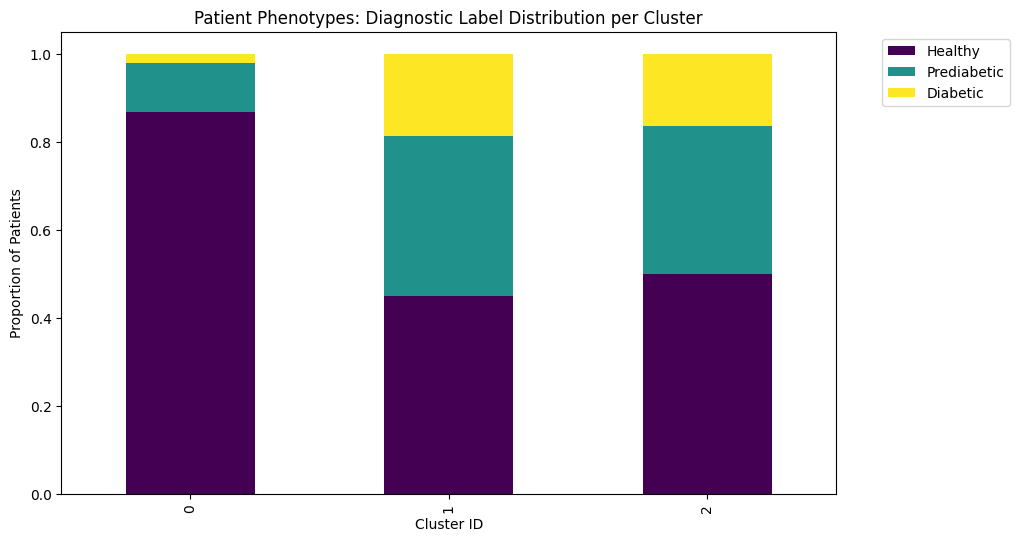

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_id'] = kmeans.fit_predict(X_cluster)

cluster_composition = pd.crosstab(df['cluster_id'], df[TARGET_COL], normalize='index')
cluster_composition.columns = ['Healthy', 'Prediabetic', 'Diabetic']

cluster_composition.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Patient Phenotypes: Diagnostic Label Distribution per Cluster')
plt.ylabel('Proportion of Patients')
plt.xlabel('Cluster ID')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

PC1: 15.2%
PC2: 10.5%
Cumulative: 25.7%


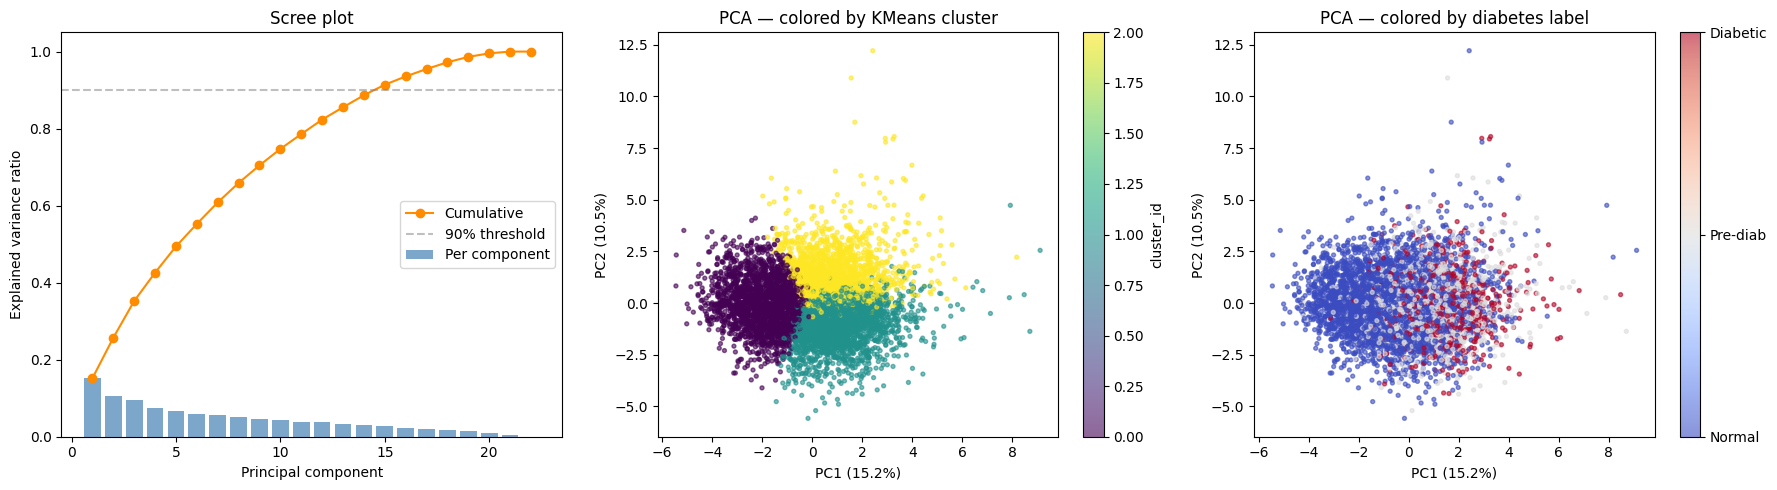

In [ ]:
pca_full = PCA().fit(X_cluster)
pca_2d   = PCA(n_components=2).fit(X_cluster)
X_2d     = pca_2d.transform(X_cluster)

print(f'PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print(f'Cumulative: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ratios = pca_full.explained_variance_ratio_
cum    = np.cumsum(ratios)
axes[0].bar(range(1, len(ratios)+1), ratios, color='steelblue', alpha=0.7, label='Per component')
axes[0].plot(range(1, len(cum)+1), cum, 'o-', color='darkorange', label='Cumulative')
axes[0].axhline(0.9, ls='--', color='gray', alpha=0.5, label='90% threshold')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')
axes[0].legend()

sc1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster_id'], cmap='viridis', s=8, alpha=0.6)
axes[1].set_title('PCA — colored by KMeans cluster')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[1], label='cluster_id')

sc2 = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=df[TARGET_COL], cmap='coolwarm', s=8, alpha=0.6)
axes[2].set_title('PCA — colored by diabetes label')
axes[2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
cbar = plt.colorbar(sc2, ax=axes[2], ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Normal', 'Pre-diab', 'Diabetic'])

plt.tight_layout()
plt.show()

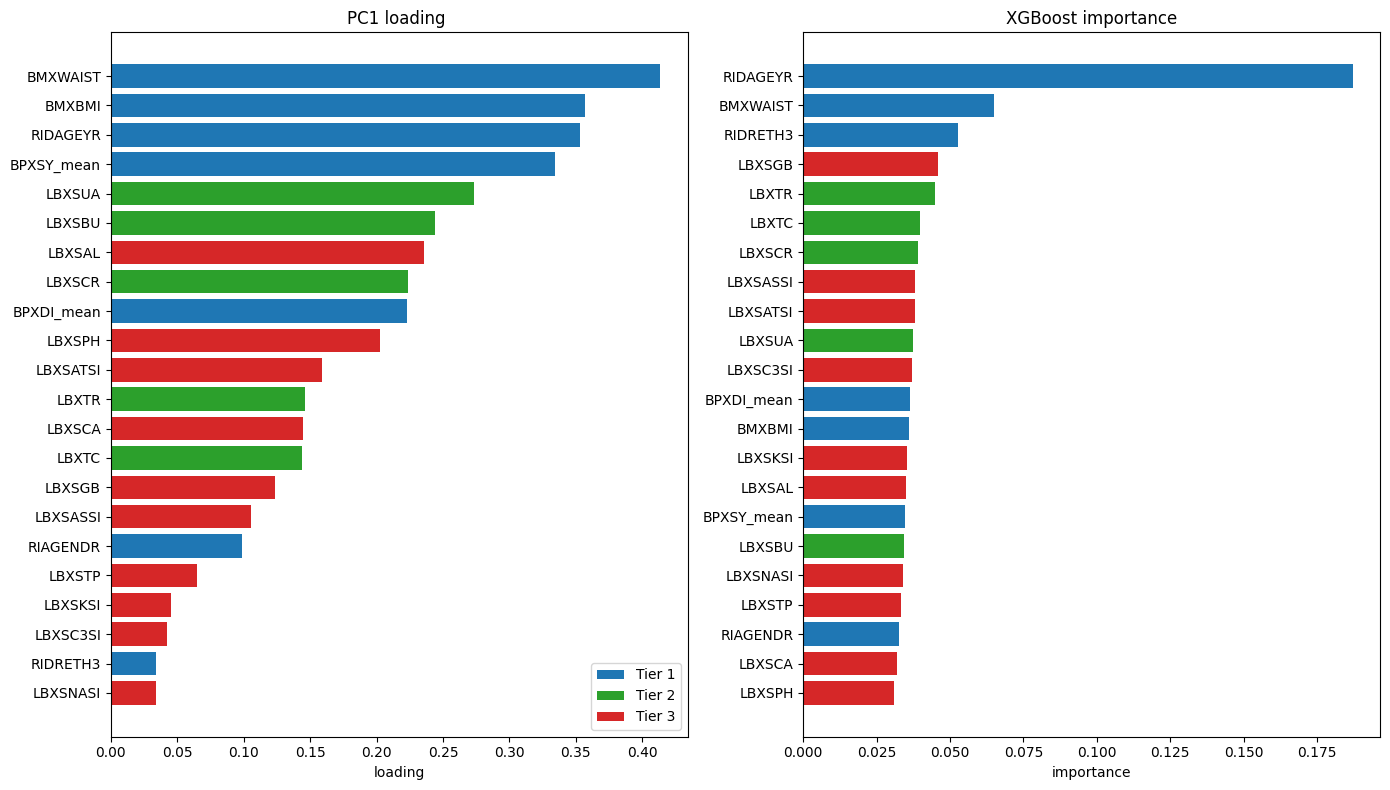

Top 5 features by |PC1 loading|:
   feature    value   tier
  BMXWAIST 0.413309 Tier 1
    BMXBMI 0.356735 Tier 1
  RIDAGEYR 0.353004 Tier 1
BPXSY_mean 0.334541 Tier 1
    LBXSUA 0.273496 Tier 2

Top 5 features by XGBoost importance:
 feature    value   tier
RIDAGEYR 0.187138 Tier 1
BMXWAIST 0.065076 Tier 1
RIDRETH3 0.052681 Tier 1
  LBXSGB 0.045996 Tier 3
   LBXTR 0.044941 Tier 2

Tier composition of top 5:
  PC1 loadings:    {'Tier 1': 4, 'Tier 2': 1}
  XGBoost imp:     {'Tier 1': 3, 'Tier 3': 1, 'Tier 2': 1}


In [ ]:
feature_to_tier = {f: 'Tier 1' for f in FEATURE_COLS_T1}
feature_to_tier.update({f: 'Tier 2' for f in FEATURE_COLS_T2})
feature_to_tier.update({f: 'Tier 3' for f in FEATURE_COLS_T3})

tier_colors = {'Tier 1': '#1f77b4', 'Tier 2': '#2ca02c', 'Tier 3': '#d62728'}

loading_df = pd.DataFrame({
    'feature': ALL_FEATURE_COLS,
    'value':   np.abs(pca_full.components_[0]),
    'tier':    [feature_to_tier[f] for f in ALL_FEATURE_COLS],
}).sort_values('value', ascending=True)

imp_df = pd.DataFrame({
    'feature': ALL_FEATURE_COLS,
    'value':   best.model.feature_importances_,
    'tier':    [feature_to_tier[f] for f in ALL_FEATURE_COLS],
}).sort_values('value', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, df_plot, title, xlabel in [
    (axes[0], loading_df, 'PC1 loading ', 'loading'),
    (axes[1], imp_df,     'XGBoost importance',     'importance'),
]:
    ax.barh(df_plot['feature'], df_plot['value'],
            color=[tier_colors[t] for t in df_plot['tier']])
    ax.set_title(title)
    ax.set_xlabel(xlabel)

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor=c, label=t) for t, c in tier_colors.items()],
               loc='lower right')
plt.tight_layout()
plt.show()

print('Top 5 features by |PC1 loading|:')
print(loading_df.sort_values('value', ascending=False).head(5).to_string(index=False))
print('\nTop 5 features by XGBoost importance:')
print(imp_df.sort_values('value', ascending=False).head(5).to_string(index=False))
print('\nTier composition of top 5:')
print(f"  PC1 loadings:    {loading_df.sort_values('value', ascending=False).head(5)['tier'].value_counts().to_dict()}")
print(f"  XGBoost imp:     {imp_df.sort_values('value', ascending=False).head(5)['tier'].value_counts().to_dict()}")

In [ ]:
test_probas_shifted = best_probas.copy()
for c in range(3):
    test_probas_shifted[:, c] /= optimal_thresholds[c]
calibrated_preds = np.argmax(test_probas_shifted, axis=1)

f1_cal = f1_score(y_test, calibrated_preds, average='macro')
f1_cal_per = f1_score(y_test, calibrated_preds, average=None)
print(f'After threshold calibration — Macro F1: {f1_cal:.4f}')
print(f'F1 per class (Normal / Pre-diab / Diabetic): '
      f'{f1_cal_per[0]:.3f} / {f1_cal_per[1]:.3f} / {f1_cal_per[2]:.3f}')

After threshold calibration — Macro F1: 0.5424
F1 per class (Normal / Pre-diab / Diabetic): 0.769 / 0.478 / 0.381


In [ ]:
df_test['calibrated_pred'] = calibrated_preds
cluster_info = df[['SEQN', 'cluster_id']].copy()
df_test = pd.merge(df_test, cluster_info, on='SEQN', how='left')

results = []
for cid in sorted(df_test['cluster_id'].unique()):
    subset = df_test[df_test['cluster_id'] == cid]
    f1_macro = f1_score(subset[TARGET_COL], subset['calibrated_pred'],
                        average='macro', zero_division=0)
    f1_per_cls = f1_score(subset[TARGET_COL], subset['calibrated_pred'],
                          average=None, zero_division=0, labels=[0, 1, 2])
    results.append({
        'cluster_id':     cid,
        'n':              len(subset),
        'macro_f1':       round(f1_macro, 3),
        'f1_normal':      round(f1_per_cls[0], 3),
        'f1_prediabetic': round(f1_per_cls[1], 3),
        'f1_diabetic':    round(f1_per_cls[2], 3),
    })

cluster_perf = pd.DataFrame(results)
print(cluster_perf.to_string(index=False))

 cluster_id   n  macro_f1  f1_normal  f1_prediabetic  f1_diabetic
          0 419     0.468      0.937           0.333        0.133
          1 468     0.426      0.449           0.479        0.350
          2 322     0.558      0.683           0.519        0.471


In [ ]:
class Encoder(nn.Module):
  def __init__ (self, input_dim, num_classes, latent_dim = 32):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim + num_classes, 128),
        nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
    )
    self.mu_layer = nn.Linear(64, latent_dim)
    self.logvar_layer = nn.Linear(64, latent_dim)

  def forward(self, x, y_onehot):
    h = self.net(torch.cat([x, y_onehot], dim = 1))
    return self.mu_layer(h), self.logvar_layer(h)

class Decoder(nn.Module):
  def __init__(self, input_dim, num_classes, latent_dim = 32):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(latent_dim + num_classes, 64), nn.ReLU(),
        nn.Linear(64, 128), nn.ReLU(),
        nn.Linear(128, input_dim),
    )
  def forward(self, z, y_onehot):
    return self.net(torch.cat([z, y_onehot], dim = 1))

class ConditionalVAE(nn.Module):
  def __init__(self, input_dim, num_classes, latent_dim = 8):
    super().__init__()
    self.encoder = Encoder(input_dim, num_classes, latent_dim)
    self.decoder = Decoder(input_dim, num_classes, latent_dim)
    self.num_classes = num_classes
    self.latent_dim = latent_dim
  def reparameterise(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    return mu + std *torch.randn_like(std)
  def forward (self, x, y_onehot):
    mu, logvar = self.encoder(x, y_onehot)
    z = self.reparameterise(mu, logvar)
    return self.decoder(z, y_onehot), mu, logvar

  @staticmethod
  def elbo_loss(x_recon, x, mu, logvar, beta = 0.5):
    recon = F.mse_loss(x_recon, x, reduction = 'mean')
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon + beta * kl)
  def sample(self, n, class_label, device):
    self.eval()
    with torch.no_grad():
      z = torch.randn(n, self.latent_dim, device = device)
      y = torch.zeros(n, self.num_classes, device = device)
      y[:, class_label] = 1.0
      return self.decoder(z, y).cpu().numpy()

In [ ]:
CATEGORICAL_COLS = ['RIAGENDR', 'RIDRETH3']
CONTINUOUS_COLS = [c for c in ALL_FEATURE_COLS if c not in CATEGORICAL_COLS]

cat_feature_indices = [ALL_FEATURE_COLS.index(c) for c in CATEGORICAL_COLS]
cont_feature_indices = [ALL_FEATURE_COLS.index(c) for c in CONTINUOUS_COLS]
X_train_cont = X_train[:, cont_feature_indices]
X_test_cont = X_test[:, cont_feature_indices]
scaler = StandardScaler()
X_train_cont_scaled = scaler.fit_transform(X_train_cont)
X_test_cont_scaled = scaler.transform(X_test_cont)

majority_n = max(Counter(y_train).values())
smote_target_counts = {0: 2195, 1: 2195, 2: 1800}

def train_cvae(X_train, y_train, num_classes, latent_dim = 8, epochs = 200,
               batch_size =256, lr = 3e-4, beta = 0.5, save_path = 'cvae_model.pt'):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model = ConditionalVAE(X_train.shape[1], num_classes, latent_dim).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr = lr)
  Y_onehot = np.eye(num_classes)[y_train]
  loader = DataLoader(
      TensorDataset(
          torch.tensor(X_train, dtype = torch.float32),
          torch.tensor(Y_onehot, dtype = torch.float32)),
      batch_size = batch_size, shuffle = True
  )
  model.train()
  for epoch in range(1, epochs + 1):
    total = 0.0
    for xb, yb in loader:
      xb, yb = xb.to(device), yb.to(device)
      beta = min(0.3, epoch/100)
      xb_noisy = xb + 0.02 * torch.randn_like(xb)
      x_recon, mu, logvar = model(xb_noisy,yb)
      loss = ConditionalVAE.elbo_loss(x_recon, xb, mu, logvar, beta)
      optimizer.zero_grad(); loss.backward(); optimizer.step()
      total += loss.item() * xb.size(0)
    if epoch %20 == 0 or epoch ==1:
      print(f" Epoch{epoch:>3}/{epochs} ELBO: {total/len(X_train):.4f}")
  return model, device

def cvae_oversample(X_train_cont_scaled, X_train_full, y_train, target_counts=None, latent_dim=8,
                    epochs=200, batch_size=256, lr=1e-3, beta=0.5, random_state=42,):
    torch.manual_seed(random_state)
    np.random.seed(random_state)
    classes = sorted(np.unique(y_train))
    num_classes = len(classes)

    counts = Counter(y_train)

    if target_counts is None:
        target_counts = {0: 1500, 1: 2195, 2: 1800}

    print(f"Current {dict(counts)} -> target: {target_counts}")

    model, device = train_cvae(X_train_cont_scaled, y_train, num_classes, latent_dim, epochs, batch_size, lr, beta,)
    X_parts = [X_train_full]
    y_parts = [y_train]
    quality_rows = []
    for cls in classes:
        need = target_counts[cls] - counts[cls]
        if need <= 0:
            continue

        print(f"\nGenerating {need} synthetic samples for class {cls}")
        samples = []

        for _ in range(need // 256 + 1):
            batch = model.sample(min(256, need),cls,device)
            samples.append(batch)

        X_syn_cont = np.vstack(samples)[:need]
        real_rows = X_train_full[y_train == cls]
        real_cat = real_rows[:, cat_feature_indices]
        idx = np.random.choice(len(real_cat),size=need,replace=True)

        cat_part = real_cat[idx]
        X_syn_full = np.zeros((need, X_train_full.shape[1]))

        X_syn_full[:, cont_feature_indices] = X_syn_cont
        X_syn_full[:, cat_feature_indices] = cat_part
        X_parts.append(X_syn_full)

        y_parts.append(np.full(need,cls, dtype=y_train.dtype))
        real_cont = X_train_cont_scaled[y_train == cls]
        mean_drift = np.mean(np.abs(real_cont.mean(axis=0) - X_syn_cont.mean(axis=0)))
        std_drift = np.mean(np.abs(real_cont.std(axis=0) -X_syn_cont.std(axis=0)))
        dup_rate = (pd.DataFrame(X_syn_cont).duplicated().mean())
        quality_rows.append({'class': cls,'mean_drift': mean_drift,'std_drift': std_drift,'duplicate_rate': dup_rate,})

        print(f"Mean drift: {mean_drift:.4f}")
        print(f"Std drift: {std_drift:.4f}")
        print(f"Duplicate rate: {dup_rate:.4f}")

    quality_df = pd.DataFrame(quality_rows)

    print("\nSynthetic Quality Diagnostics")
    print(quality_df)

    X_res = np.vstack(X_parts)
    y_res = np.concatenate(y_parts)
    idx = np.random.permutation(len(y_res))
    return X_res[idx], y_res[idx]

In [ ]:
from sklearn.metrics import cohen_kappa_score, mean_absolute_error

def run_all_conditions(X_train_scaled_cont, X_train_full, y_train,
    X_test_scaled_cont, X_test_full, y_test, smote_target_counts, cat_feature_indices=None,):

    comparison_rows = []
    def fit_eval(X_tr, y_tr, X_te, label,sample_weight=None,):

        clf = XGBClassifier(**top[0]['config'], objective='multi:softprob', num_class=3,
            use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_SEED,)

        clf.fit(X_tr, y_tr, sample_weight=sample_weight,)

        preds = clf.predict(X_te)
        macro_f1 = f1_score(y_test, preds,average='macro')
        qwk = cohen_kappa_score(y_test, preds,weights='quadratic')
        ordinal_mae = mean_absolute_error(y_test,preds)

        print(f"\n{'='*52}")
        print(f"Condition: {label}")
        print(f"Train dist: {dict(Counter(y_tr))}")
        print(classification_report(y_test, preds))

        print(f"Macro F1: {macro_f1:.4f}")
        print(f"QWK: {qwk:.4f}")
        print(f"Ordinal MAE: {ordinal_mae:.4f}")

        comparison_rows.append({'model': label, 'macro_f1': macro_f1, 'qwk': qwk, 'ordinal_mae': ordinal_mae,})

    fit_eval(X_train_full, y_train, X_test_full, "No resampling")

    sw = compute_sample_weight(class_weight='balanced',y=y_train)
    fit_eval(X_train_full,y_train, X_test_full,"Class weights",sw)

    X_sm_cont, y_sm = SMOTE(sampling_strategy=smote_target_counts,random_state=42,).fit_resample(X_train_scaled_cont, y_train)
    real_cat = X_train_full[:, cat_feature_indices]
    idx = np.random.choice(len(real_cat),size=len(X_sm_cont), replace=True)
    X_sm_full = np.zeros((len(X_sm_cont), X_train_full.shape[1]))
    X_sm_full[:, cont_feature_indices] = X_sm_cont
    X_sm_full[:, cat_feature_indices] = real_cat[idx]
    fit_eval(X_sm_full, y_sm, X_test_full, "SMOTE")

    if cat_feature_indices is not None:
        X_nc, y_nc = SMOTENC(categorical_features=cat_feature_indices,
            sampling_strategy=smote_target_counts, random_state=42,).fit_resample(X_train_full, y_train)
        fit_eval(X_nc, y_nc, X_test_full, "SMOTE-NC")

    X_cv, y_cv = cvae_oversample(X_train_scaled_cont, X_train_full, y_train,
        target_counts=smote_target_counts, latent_dim=16, epochs=100, lr=3e-4,batch_size=128,)
    fit_eval(X_cv, y_cv, X_test_full,"cVAE oversampling")

    comparison_df = pd.DataFrame(comparison_rows)
    print("\nFinal Comparison Table")
    print(comparison_df.sort_values('macro_f1',ascending=False))

run_all_conditions(X_train_cont_scaled, X_train, y_train, X_test_cont_scaled, X_test,
    y_test, smote_target_counts, cat_feature_indices,)


Condition: No resampling
Train dist: {np.int64(0): 2195, np.int64(2): 451, np.int64(1): 981}
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       732
           1       0.44      0.40      0.42       327
           2       0.40      0.30      0.34       150

    accuracy                           0.65      1209
   macro avg       0.53      0.51      0.52      1209
weighted avg       0.63      0.65      0.63      1209

Macro F1: 0.5174
QWK: 0.4487
Ordinal MAE: 0.4078

Condition: Class weights
Train dist: {np.int64(0): 2195, np.int64(2): 451, np.int64(1): 981}
              precision    recall  f1-score   support

           0       0.83      0.72      0.77       732
           1       0.42      0.48      0.45       327
           2       0.41      0.53      0.46       150

    accuracy                           0.63      1209
   macro avg       0.55      0.58      0.56      1209
weighted avg       0.67      0.63      0.65      1209

M

In [ ]:
from sklearn.metrics import confusion_matrix

tier_name_map = {
    'Tier 1 (zero-cost)':  'T1',
    'Tier 1+2 (moderate)': 'T1+T2',
    'Tier 1+2+3 (full)':   'T1+T2+T3',
}

for tier_label, feature_cols in tier_configs:
    Xtr, Xca, Xte, ytr, yca, yte = split_data(df, feature_cols=feature_cols)

    sw = compute_sample_weight(class_weight='balanced', y=ytr)

    clf = XGBClassifier(**top[0]['config'],
                        objective='multi:softprob',
                        num_class=3,
                        random_state=RANDOM_SEED)
    clf.fit(Xtr, ytr, sample_weight=sw)

    preds = clf.predict(Xte)
    cm = confusion_matrix(yte, preds)
    cm_prob = np.round(cm / cm.sum(axis=1, keepdims=True), 3)
    short = tier_name_map[tier_label]
    print(f"'{short}': np.array({cm_prob.tolist()}),")

Train: 3627 | Cal: 1209 | Test: 1209
'T1': np.array([[0.684, 0.187, 0.128], [0.251, 0.355, 0.394], [0.153, 0.387, 0.46]]),
Train: 3627 | Cal: 1209 | Test: 1209
'T1+T2': np.array([[0.706, 0.22, 0.074], [0.235, 0.508, 0.257], [0.093, 0.427, 0.48]]),
Train: 3627 | Cal: 1209 | Test: 1209
'T1+T2+T3': np.array([[0.724, 0.227, 0.049], [0.278, 0.48, 0.242], [0.127, 0.34, 0.533]]),
